# Импорты

In [1]:
# ячейка для гугл колаба
#!pip install catboost neuralforecast statsforecast -q

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 62.0/62.0 kB 3.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 97.1/97.1 MB 10.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 275.6/275.6 kB 18.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 354.6/354.6 kB 17.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 348.2/348.2 kB 13.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 281.0/281.0 kB 4.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 857.3/857.3 kB 32.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 73.0/73.0 MB 9.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 37.3/37.3 MB 31.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 40.3/40.3 kB 1.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 419.5/419.5 kB 23.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 87.2/87.2 kB 4.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━

In [1]:
import pandas as pd
import numpy as np
from sklearn.preprocessing import StandardScaler, RobustScaler, QuantileTransformer
from catboost import CatBoostRegressor
from neuralforecast import NeuralForecast
from neuralforecast.models import PatchTST
import plotly.express as px
import plotly.graph_objects as go
from plotly.subplots import make_subplots
from statsforecast import StatsForecast
from statsforecast.models import AutoARIMA, AutoETS, AutoTheta
from statsmodels.graphics.tsaplots import plot_acf
import random
import matplotlib.pyplot as plt
from tqdm import tqdm
import seaborn as sns

C:\Users\albed\PycharmProjects\TS_hw03_normalise\venv\lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
2026-03-20 18:44:17,654	INFO util.py:154 -- Missing packages: ['ipywidgets']. Run `pip install -U ipywidgets`, then restart the notebook server for rich notebook output.
2026-03-20 18:44:17,742	INFO util.py:154 -- Missing packages: ['ipywidgets']. Run `pip install -U ipywidgets`, then restart the notebook server for rich notebook output.


In [ ]:
from utils.preprocessing import *
from utils.experiments import *
from utils.metrics import *

In [3]:
def seed_everything(seed=42):
    random.seed(seed)
    np.random.seed(seed)
seed_everything()

In [4]:
import warnings
warnings.filterwarnings("ignore")

# Гипотеза

Нормализация по рядам особенно важна для глобальных нейронных
моделей, но влияет неоднозначно для моделей из разных классов.
- Зафиксировать бейзлайны и две глобальные модели для основных
экспериментов (например, CatBoost и PatchTST).
- Сравнить качество моделей (бейзлайнов тоже) с применением
StandardScaling и без его применения.
- Сравнить качество моделей с применением не менее двух других вариантов
скейлинга (QuantileScaling, RobustScaling).
- Отдельно проанализировать, одинаково ли влияет нормализация на модели
разных классов.


# Данные

In [5]:
url = "https://raw.githubusercontent.com/Mcompetitions/M4-methods/master/Dataset/Train/Monthly-train.csv"
df = pd.read_csv(url)
df.head(10)

,V1,V2,V3,V4,V5,V6,V7,V8,V9,V10,...,V2786,V2787,V2788,V2789,V2790,V2791,V2792,V2793,V2794,V2795
0,M1,8000.0,8350.0,8570.0,7700.0,7080.0,6520.0,6070.0,6650.0,6830.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,M2,2440.0,2490.0,2710.0,2290.0,1960.0,1990.0,1960.0,2530.0,2640.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,M3,2670.0,2590.0,2784.0,2816.0,2888.0,2906.0,2839.0,2860.0,2798.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,M4,7264.0,7215.0,7022.0,7040.0,6966.0,6984.0,7025.0,7082.0,6956.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,M5,4210.0,4290.0,4250.0,4320.0,4320.0,4330.0,4320.0,4260.0,4220.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
5,M6,5600.0,5700.0,5700.0,5700.0,5600.0,5600.0,5500.0,5500.0,5500.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
6,M7,865.0,902.0,909.0,945.0,953.0,959.0,956.0,949.0,932.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
7,M8,796.0,856.0,848.0,890.0,909.0,901.0,907.0,927.0,930.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
8,M9,8980.0,8970.0,9120.0,9080.0,9600.0,9600.0,9600.0,9340.0,9410.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
9,M10,16960.0,17170.0,17420.0,17680.0,17670.0,17750.0,17600.0,17440.0,17490.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [6]:
df = df.sample(150) # берём случайные 150 рядов

In [7]:
df.head(10)

,V1,V2,V3,V4,V5,V6,V7,V8,V9,V10,...,V2786,V2787,V2788,V2789,V2790,V2791,V2792,V2793,V2794,V2795
32771,M32772,3377.863366,3532.430711,3739.548836,3715.226318,3667.970782,3181.870663,3689.094063,3947.762278,3503.254612,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
39512,M39513,723.730000,725.260000,728.070000,715.100000,735.800000,744.950000,755.940000,758.560000,763.240000,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
43581,M43582,2902.625600,2977.490200,2975.106700,3057.995300,3218.161700,3032.579100,3049.839300,3028.854500,3113.818700,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2975,M2976,7029.200000,6969.630000,6940.980000,7125.790000,7323.210000,7521.920000,7929.080000,7869.200000,8123.600000,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3377,M3378,5958.148090,6017.051050,6004.066130,5996.197670,5976.843310,5920.007310,5881.587770,5912.549120,5913.528850,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3792,M3793,3285.498630,3580.264450,3803.156460,3925.455690,4173.211570,3563.205850,3966.262080,3932.888950,2704.811490,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
34123,M34124,2151.024194,956.091872,864.642295,582.758709,488.705151,2343.494495,2545.011113,2346.846579,1391.231212,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
19847,M19848,5800.000000,5800.000000,6000.000000,6000.000000,5400.000000,4800.000000,4400.000000,4100.000000,4000.000000,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
10421,M10422,1000.000000,1005.000000,1033.000000,1028.000000,1029.000000,1021.000000,1019.000000,1016.000000,1003.000000,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
28533,M28534,6320.000000,6339.000000,6370.000000,6621.000000,6672.000000,6664.000000,6678.000000,6680.000000,6708.000000,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [8]:
'Пропусков нет' if df.notna().all().all() else 'Нужно заполнить пропуски'

'Нужно заполнить пропуски'

Проверим данные на наличие пропусков и заполним их последним известным значением. Видно, что пропуски начинаются с определённой колонки, т.е. с определённого момента времени. Т.к. это тренировочный набор, полагаю подразумевается, что пропуски будут заполнены прогнозами моделей.

In [9]:
df = df.melt(id_vars=['V1'], var_name='t', value_name='y') # приводим датасет в более удобоваримый вид
df = df.rename(columns={'V1': 'unique_id'})

In [10]:
df.dropna(inplace=True)

In [11]:
df

,unique_id,t,y
0,M32772,V2,3377.863366
1,M39513,V2,723.730000
2,M43582,V2,2902.625600
3,M2976,V2,7029.200000
4,M3378,V2,5958.148090
...,...,...,...
160413,M27368,V1071,19750.000000
160563,M27368,V1072,19900.000000
160713,M27368,V1073,19760.000000
160863,M27368,V1074,19800.000000


In [12]:
fig_opt = go.Figure()
color_sequence = px.colors.qualitative.Plotly
rand_ids = np.random.randint(0, df.shape[0], size=(10))
for idx, row_id in enumerate(rand_ids):
    row = df.iloc[row_id]
    curr_series = df[df['unique_id'] == row['unique_id']]
    fig_opt.add_trace(go.Scatter(y=curr_series.y,x=curr_series.t, mode='lines',line=dict(color=color_sequence[idx % len(color_sequence)], width=2), name=str(row['unique_id'])))
    idx += 1
fig_opt.update_layout(title=f"10 случайных рядов из датасета", xaxis_title="дата", yaxis_title="значение", hovermode='closest')
fig_opt.show()

Видим, что ряды невыровненные, заканчиваются в разное время + имеют разный масштаб и разные распределения. Где-то тренд более выражен, где-то более заметна сезонность. Т.к. данные брались за каждый месяц, есть смысл смотреть на горизонт в полтора года, чтобы иметь возможность захватить все потенциальные паттерны сезонности

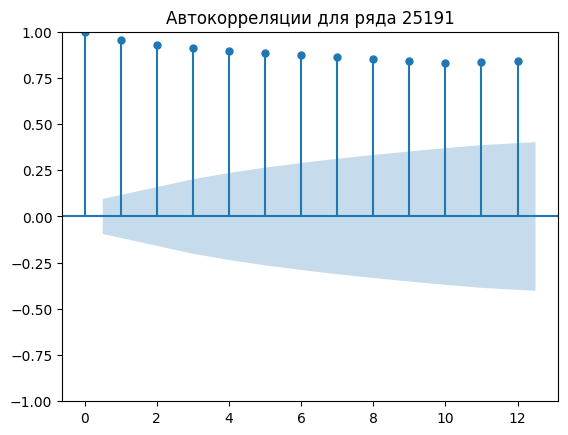

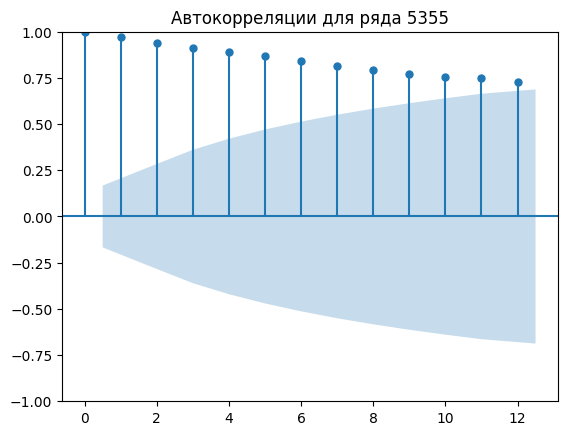

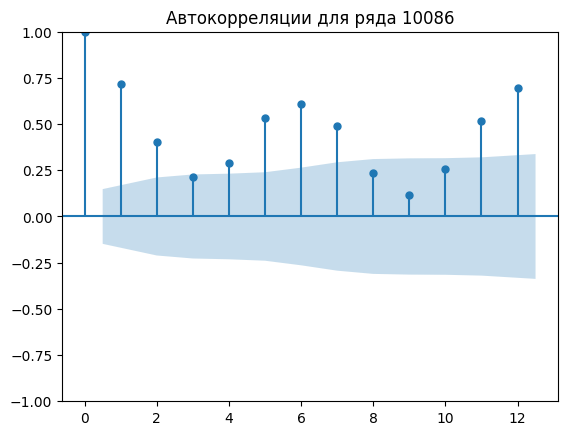

In [13]:
# проверим автокорреляцию за год
for i in [0, 4, 9]:
  data = df[df['unique_id'] == df.iloc[rand_ids[i]].unique_id].copy()
  acf = plot_acf(data['y'], lags=12, title=f'Автокорреляции для ряда {rand_ids[i]}')
  plt.show()

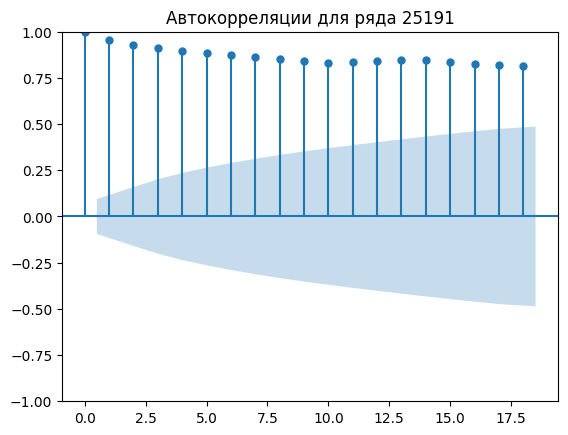

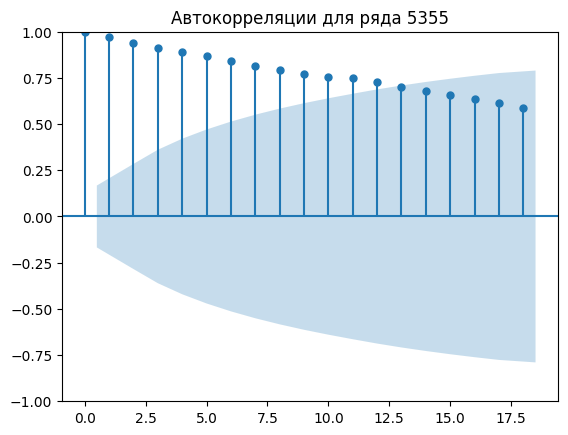

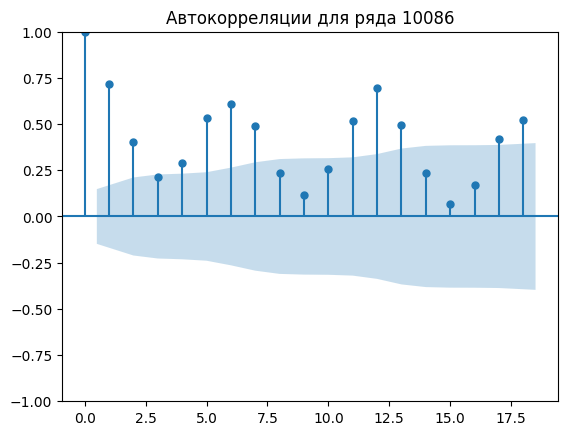

In [14]:
# а теперь а 18 месяцев
for i in [0, 4, 9]:
  data = df[df['unique_id'] == df.iloc[rand_ids[i]].unique_id].copy()
  acf = plot_acf(data['y'], lags=18, title=f'Автокорреляции для ряда {rand_ids[i]}')
  plt.show()

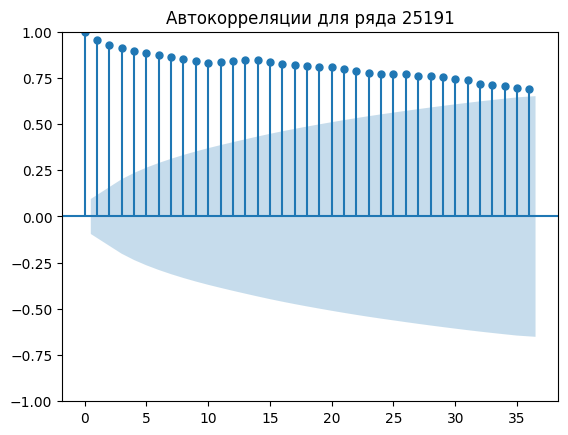

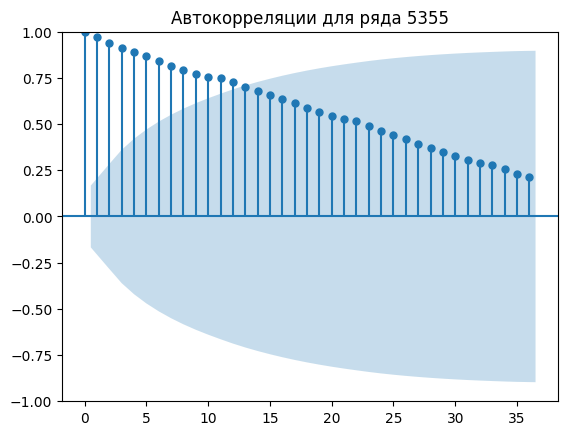

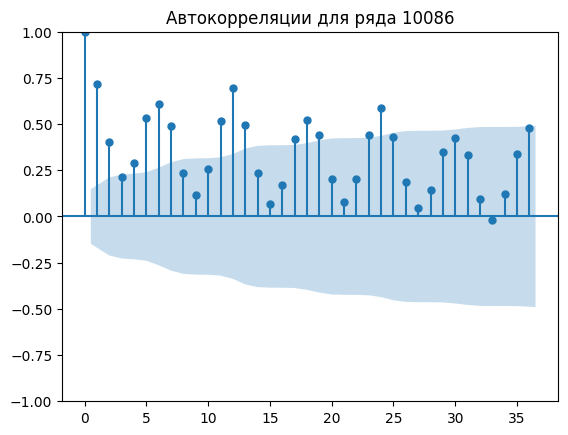

In [15]:
# наконец, посмотрим, как ведут себя ряды в промежутке 3 лет
for i in [0, 4, 9]:
  data = df[df['unique_id'] == df.iloc[rand_ids[i]].unique_id].copy()
  acf = plot_acf(data['y'], lags=36, title=f'Автокорреляции для ряда {rand_ids[i]}')
  plt.show()

По автокорреляциям тоже заметно, насколько отличаются ряды между собой: у одних значимость лагов постепенно и монотонно убывает, у других ACF имеет волнообразную траекторию, свидетельствующую о выраженной сезонности.

## Деление на тренировочную и тестовые выборки

In [32]:
train, test = train_test_split(df)

In [33]:
REQUIRED_COLS = ['unique_id', 'ds', 'y']
train = train[REQUIRED_COLS]
test = test[REQUIRED_COLS]

In [34]:
train

,unique_id,ds,y
0,M10158,0,1526.0
1,M10158,1,1544.0
2,M10158,2,1519.0
3,M10158,3,1522.0
4,M10158,4,1527.0
...,...,...,...
32975,M986,283,2147.0
32976,M986,284,2129.0
32977,M986,285,2116.0
32978,M986,286,2116.0


# Метрики

Будем использовать следующие метрики: **SMAPE** (она является основной в M4 соревновании + не зависит от масштаба и симметрична), **MASE** (помогает сравнить прогноз модели с наивным прогнозом, что тоже немаловажно, особенно при сравнении разных моделей + нормализует ошибку относительно сложности ряда),  RMSE (сильно штрафует большие ошибки + поможет увидеть, не ломает ли нормализация хвосты распределения)

# Бейзлайн

In [17]:
scalers = {
    "none": None,
    "standard": StandardScaler(),
    "robust": RobustScaler(),
    "quantile": QuantileTransformer(output_distribution='normal')
}

В бейзлайне не участвуют наивные модели, поскольку для них решкалирование с обратным преобразванием прогноза ничего не изменит.

In [22]:
all_results = []
ids = df['unique_id'].unique()
plot_ids = [df.iloc[r]['unique_id'] for r in rand_ids[:3]]
example_plots = {}

for scaler_name, scaler in scalers.items():
  print(f"\nRunning scaler: {scaler_name}")

  for uid in tqdm(ids):
    series_df = df[df['unique_id'] == uid].copy()
    series_df['ds'] = np.arange(len(series_df))

    try:
      results, forecast, train_df, test_df = process_series(
          series_df,
          scaler=scaler,
          use_boxcox=True
      )

      for r in results:
        r['unique_id'] = uid
        r['scaler'] = scaler_name
        all_results.append(r)

      if uid in plot_ids:
        if uid not in example_plots:
          example_plots[uid] = {
              'train': train_df,
              'test': test_df,
              'forecasts': {}
          }

        example_plots[uid]['forecasts'][scaler_name] = forecast

    except Exception as e:
      print(f"Error in {uid}: {e}")


Running scaler: none


100%|██████████| 150/150 [01:43<00:00,  1.44it/s]



Running scaler: standard


100%|██████████| 150/150 [01:49<00:00,  1.36it/s]



Running scaler: robust


100%|██████████| 150/150 [01:40<00:00,  1.50it/s]



Running scaler: quantile


100%|██████████| 150/150 [01:56<00:00,  1.29it/s]


In [23]:
results_df = pd.DataFrame(all_results)

summary = results_df.groupby('model').agg({
    'sMAPE': 'mean',
    'RMSE': 'mean',
    'MASE': 'mean'
}).reset_index()
summary.sort_values('MASE')

,model,sMAPE,RMSE,MASE
0,AutoARIMA,11.073754,inf,inf
1,AutoETS,11.038958,inf,inf
2,AutoTheta,12.699741,inf,inf


In [24]:
fig = px.box(results_df, x='model', y='MASE', title='Распределение MASE')
fig.show()

In [25]:
models = ['AutoARIMA', 'AutoETS', 'AutoTheta']

for uid, data in example_plots.items():
  train_df = data['train']
  test_df = data['test']
  forecasts_dict = data['forecasts']

  for model in models:

    fig = go.Figure()
    fig.add_trace(go.Scatter(
        x=train_df.ds,
        y=train_df.y,
        name="train",
        line=dict(color='blue')
    ))

    fig.add_trace(go.Scatter(
        x=test_df.ds,
        y=test_df.y,
        name="test",
        line=dict(dash="dash", color='grey')
    ))

    for idx, (scaler_name, forecast) in enumerate(forecasts_dict.items()):
      fig.add_trace(go.Scatter(
          x=test_df.ds,
          y=forecast[model],
          name=f"{model} ({scaler_name})",
          mode='lines',
          line=dict(
              color=color_sequence[idx % len(color_sequence)],
              width=2
          )
      ))

    fig.update_layout(
        title=f"{model} | Series {uid} | Scaling comparison",
        xaxis_title="Дата",
        yaxis_title="Значение"
    )
    fig.show()

Видим, что для моделей бейзлайна выбор способа нормализации не улучшает результат, в основном это влияет на угол наклона траектории предсказания. В отдельных случаях прогноз статистических моделей стал хуже по качеству после нормализации. Для моделей этого класса куда более эффективны иные методы предобработки данных: извлечение тренда, взятие разности вместо истинных значений для обучения и т.д. Возможно, стоило провести эксперимент над ними без Box-Cox преобразования, т.к. оно тоже по своей сути стабилизирует распределение значений. С другой стороны, это стандартный шаг при использовании статистических моделей, и в текущей реализации обучение ближе к "полевым" условиям.

# Эксперимент

## PatchTST

In [35]:
patch_results = []
patch_forecasts = {}

for scaler_name, scaler in tqdm(scalers.items()):
  train_scaled, test_scaled, scalers_dict = apply_scaling_train(train, test, scaler)
  forecast = run_patchtst(train_scaled)
  if scaler is not None:
    forecast = inverse_scaling(forecast, scalers_dict)
  patch_forecasts[scaler_name] = forecast
  for uid in test['unique_id'].unique():
    y_true = test[test['unique_id'] == uid]['y'].values
    y_pred = forecast[forecast['unique_id'] == uid]['PatchTST'].values
    y_train = train[train['unique_id'] == uid]['y'].values
    patch_results.append({
        'unique_id': uid,
        'model': 'PatchTST',
        'scaler': scaler_name,
        'sMAPE': smape(y_true, y_pred),
        'RMSE': rmse(y_true, y_pred),
        'MASE': mase(y_true, y_pred, y_train)
    })

  0%|          | 0/4 [00:00<?, ?it/s]INFO:lightning_fabric.utilities.seed:Seed set to 1
INFO:pytorch_lightning.utilities.rank_zero:GPU available: False, used: False
INFO:pytorch_lightning.utilities.rank_zero:TPU available: False, using: 0 TPU cores
INFO:pytorch_lightning.utilities.rank_zero:💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.


┏━━━┳━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━┳━━━━━━━┳━━━━━━━┓
┃   ┃ Name         ┃ Type              ┃ Params ┃ Mode  ┃ FLOPs ┃
┡━━━╇━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━╇━━━━━━━╇━━━━━━━┩
│ 0 │ loss         │ MAE               │      0 │ train │     0 │
│ 1 │ padder_train │ ConstantPad1d     │      0 │ train │     0 │
│ 2 │ scaler       │ TemporalNorm      │      0 │ train │     0 │
│ 3 │ model        │ PatchTST_backbone │  409 K │ train │     0 │
└───┴──────────────┴───────────────────┴────────┴───────┴───────┘

Trainable params: 409 K                                                                                            
Non-trainable params: 3                                                                                            
Total params: 409 K                                                                                                
Total estimated model params size (MB): 1                                                                          
Modules in train mode: 90                                                                                          
Modules in eval mode: 0                                                                                            
Total FLOPs: 0

Output()

INFO:pytorch_lightning.utilities.rank_zero:`Trainer.fit` stopped: `max_steps=200` reached.


...

Output()

INFO:pytorch_lightning.utilities.rank_zero:`Trainer.fit` stopped: `max_steps=200` reached.


INFO:pytorch_lightning.utilities.rank_zero:GPU available: False, used: False
INFO:pytorch_lightning.utilities.rank_zero:TPU available: False, using: 0 TPU cores
INFO:pytorch_lightning.utilities.rank_zero:💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.


Output()

100%|██████████| 4/4 [11:32<00:00, 173.03s/it]


In [36]:
patch_df = pd.DataFrame(patch_results)
results_df = pd.concat([results_df, patch_df], ignore_index=True)

In [37]:
fig = px.box(patch_df, x='scaler', y='MASE',title='PatchTST: влияние нормализации')
fig.show()

По графику видно, что распределение MASE не так уж сильно меняется от стратегии нормализации. Но это ещё совсем не показатель

In [38]:
models_scalers = list(patch_forecasts.keys())

for row_idx in plot_ids:
  fig = go.Figure()
  tr = train[train['unique_id'] == row_idx]
  te = test[test['unique_id'] == row_idx]
  fig.add_trace(go.Scatter(x=tr['ds'], y=tr['y'], name="train"))
  fig.add_trace(go.Scatter(x=te['ds'], y=te['y'], name="test", line=dict(dash='dash')))

  for idx, scaler_name in enumerate(models_scalers):
    fc = patch_forecasts[scaler_name]
    y_pred = fc[fc['unique_id'] == row_idx]['PatchTST']
    fig.add_trace(go.Scatter(
        x=te['ds'],
        y=y_pred,
        name=f"PatchTST ({scaler_name})",
        line=dict(color=color_sequence[ (idx+2) % len(color_sequence)])
    ))

  fig.update_layout(title=f"PatchTST scaling comparison: {row_idx}")
  fig.show()

Наблюдается уже совсем другая картина: способ нормализации влияет на характер траектории предсказания => для PatchTST выбор метода решкалирования важен и позволяет улучшить результат для части рядов. Однозначного улучшения качества нет, но можно точно сказать, что выбор способа нормализации и сама по себе нормализация - важный шаг в обучении глобальной модели этого типа.

## CatBoost

Catboost будем обучать так же, как и статистические модели, отдельно по каждому ряду.

In [39]:
catboost_results = []
catboost_forecasts = {}

for scaler_name, scaler in tqdm(scalers.items()):
  train_scaled, test_scaled, scalers_dict = apply_scaling_train(train, test, scaler)
  preds_all = []
  for uid in train['unique_id'].unique():
    tr = train_scaled[train_scaled['unique_id'] == uid]
    te = test_scaled[test_scaled['unique_id'] == uid]

    try:
      preds = run_catboost_single(tr, te)
    except Exception as e:
      print(f"Error in {uid}: {e}")
      continue

    if scaler is not None:
      sc = scalers_dict[uid]
      preds = sc.inverse_transform(preds.reshape(-1,1)).flatten()

    y_true = test[test['unique_id'] == uid]['y'].values
    y_train = train[train['unique_id'] == uid]['y'].values

    catboost_results.append({
        'unique_id': uid,
        'model': 'CatBoost',
        'scaler': scaler_name,
        'sMAPE': smape(y_true, preds),
        'RMSE': rmse(y_true, preds),
        'MASE': mase(y_true, preds, y_train)
    })

    preds_all.append(pd.DataFrame({
        'unique_id': uid,
        'ds': te['ds'],
        'CatBoost': preds
    }))
  catboost_forecasts[scaler_name] = pd.concat(preds_all)

100%|██████████| 4/4 [11:25<00:00, 171.45s/it]


In [40]:
catboost_df = pd.DataFrame(catboost_results)
results_df = pd.concat([results_df, catboost_df], ignore_index=True)

In [41]:
fig = px.box(
    catboost_df,
    x='scaler',
    y='MASE',
    title='CatBoost: влияние нормализации'
)
fig.show()

Аналогично с PatchTST, разница в распределении метрики не сильно заметна.

In [42]:
for row_idx in plot_ids:
  fig = go.Figure()
  tr = train[train['unique_id'] == row_idx]
  te = test[test['unique_id'] == row_idx]
  fig.add_trace(go.Scatter(x=tr['ds'], y=tr['y'], name="train"))
  fig.add_trace(go.Scatter(x=te['ds'], y=te['y'], name="test", line=dict(dash='dash')))

  for idx, scaler_name in enumerate(catboost_forecasts.keys()):
    fc = catboost_forecasts[scaler_name]
    y_pred = fc[fc['unique_id'] == row_idx]['CatBoost']

    fig.add_trace(go.Scatter(
        x=te['ds'],
        y=y_pred,
        name=f"CatBoost ({scaler_name})",
        line=dict(color=color_sequence[(idx+2) % len(color_sequence)])
    ))
  fig.update_layout(title=f"CatBoost scaling: {row_idx}")
  fig.show()

Для Catboost разница оказалась менее заметна. Очевидного улучшения или ухудшения не наблюдается. Половина траекторий, где применялась разная стратегия нормализации, совпадают => для tree-based алгоритма метод и сама по себе нормализация не сильно влияют на результат. Примечательно, что от других траекторий сильнее всего отличается quantile решкалирование.

# Результаты + выводы

In [43]:
results_df # итоговый датасет по результатам экспериментов

,model,sMAPE,RMSE,MASE,unique_id,scaler
0,AutoARIMA,12.489240,392.248964,1.324750,M32772,none
1,AutoETS,12.373554,389.797714,1.311895,M32772,none
2,AutoTheta,16.396160,518.123074,1.717305,M32772,none
3,AutoARIMA,3.844942,80.552391,4.203370,M39513,none
4,AutoETS,3.440364,73.073329,3.746648,M39513,none
...,...,...,...,...,...,...
2995,CatBoost,18.150533,745.434019,2.500424,M8649,quantile
2996,CatBoost,21.290627,204.323252,1.233391,M8727,quantile
2997,CatBoost,20.330214,1077.242451,1.839190,M9061,quantile
2998,CatBoost,25.807089,781.622568,6.690499,M9114,quantile


Сначала посмотрим на показатели ошибки в общем, без разбиения на стратегии нормализации.

In [46]:
summary = results_df.groupby('model').agg({
    'sMAPE': 'mean',
    'RMSE': 'mean',
    'MASE': 'mean'
}).reset_index()
summary.sort_values('MASE')

,model,sMAPE,RMSE,MASE
4,PatchTST,10.569377,624.136803,2.872791
3,CatBoost,11.637349,652.463055,3.270474
1,AutoETS,11.038958,inf,inf
0,AutoARIMA,11.073754,inf,inf
2,AutoTheta,12.699741,inf,inf


Наличие inf значений означает, что для части рядов показатель ошибки ушёл в бесконечность. Данная проблема возникла исключительно у статистических моделей.

Теперь проверим показатели с разбиением и по модели, и по способу нормализации данных.

In [48]:
summary = results_df.groupby(['model', 'scaler']).agg({
    'MASE': 'mean',
    'sMAPE': 'mean',
    'RMSE': 'mean'
}).reset_index()
summary

,model,scaler,MASE,sMAPE,RMSE
0,AutoARIMA,none,inf,11.053032,inf
1,AutoARIMA,quantile,3.010661,11.513515,671.890366
2,AutoARIMA,robust,2.640287,10.896679,622.314657
3,AutoARIMA,standard,2.624247,10.831376,621.208536
4,AutoETS,none,inf,11.147509,inf
5,AutoETS,quantile,2.914863,11.325119,656.292979
6,AutoETS,robust,2.792350,10.875248,626.697935
7,AutoETS,standard,2.751899,10.808591,624.029807
8,AutoTheta,none,inf,13.860940,inf
9,AutoTheta,quantile,2.975986,11.933390,685.078597


Да, нормализация данных не дала ощутимой разницы на этапе предсказания для статистических моделей, но по метрикам видно, что она, по крайней мере, помогла избавиться от уходящей в бесконечность ошибки. По значениям метрик все модели вне зависимости от класса оказались очень близки, однозначного лидера нет. Не зря статистические методы до сих пор считаются сильным бейзлайном.

Наконец, посмотрим на топ-10 моделей по качеству

In [52]:
agg_sorted = summary.sort_values(
    by=['MASE', 'sMAPE', 'RMSE'],
    ascending=True
).reset_index(drop=True)

agg_sorted['rank'] = agg_sorted.index + 1
agg_sorted.head(10)

,model,scaler,MASE,sMAPE,RMSE,rank
0,AutoARIMA,standard,2.624247,10.831376,621.208536,1
1,AutoARIMA,robust,2.640287,10.896679,622.314657,2
2,AutoETS,standard,2.751899,10.808591,624.029807,3
3,PatchTST,standard,2.754981,10.303117,595.695801,4
4,PatchTST,robust,2.783325,10.344112,594.942632,5
5,AutoETS,robust,2.792350,10.875248,626.697935,6
6,AutoTheta,standard,2.804813,12.320973,664.134108,7
7,AutoTheta,robust,2.873813,12.696619,673.393104,8
8,AutoETS,quantile,2.914863,11.325119,656.292979,9
9,PatchTST,none,2.921033,10.591132,641.891437,10


По качеству в топ попали статистические модели и PatchTST. Видно, что все модели справляются хуже наивного прогноза, но на то мы и не подбирали им гиперпараметры и практически не предобрабатывали данные. Лучше всего среди методов нормализации себя проявили standard и robust. Видно, как PatchTST с применёнными robust и standard нормализациями поднялся в рейтинге на 3 позиции относительно себя же, но без решкалирования данных.

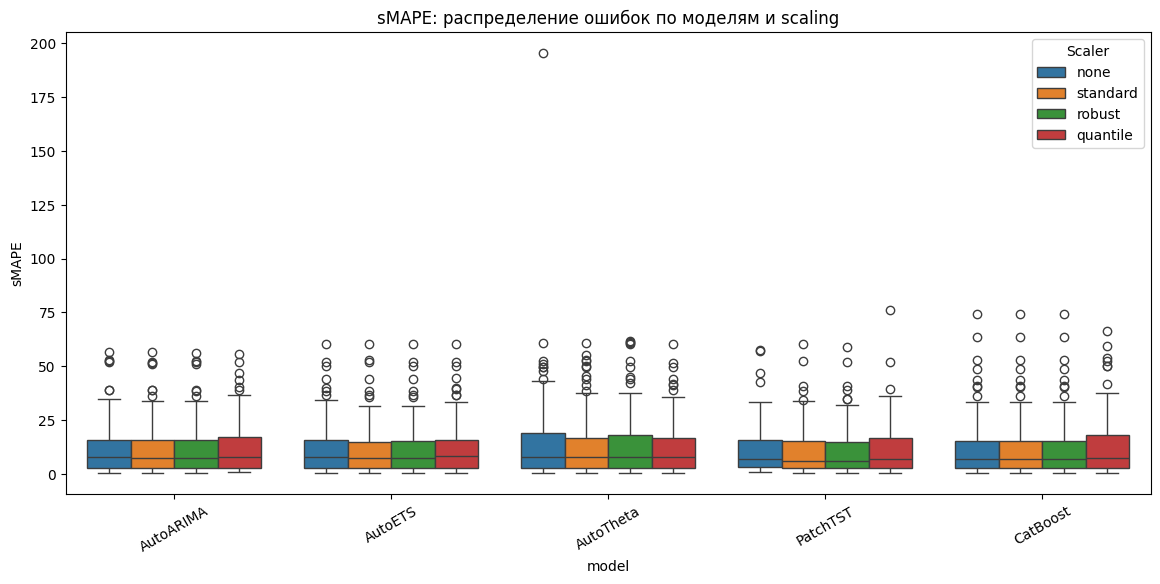

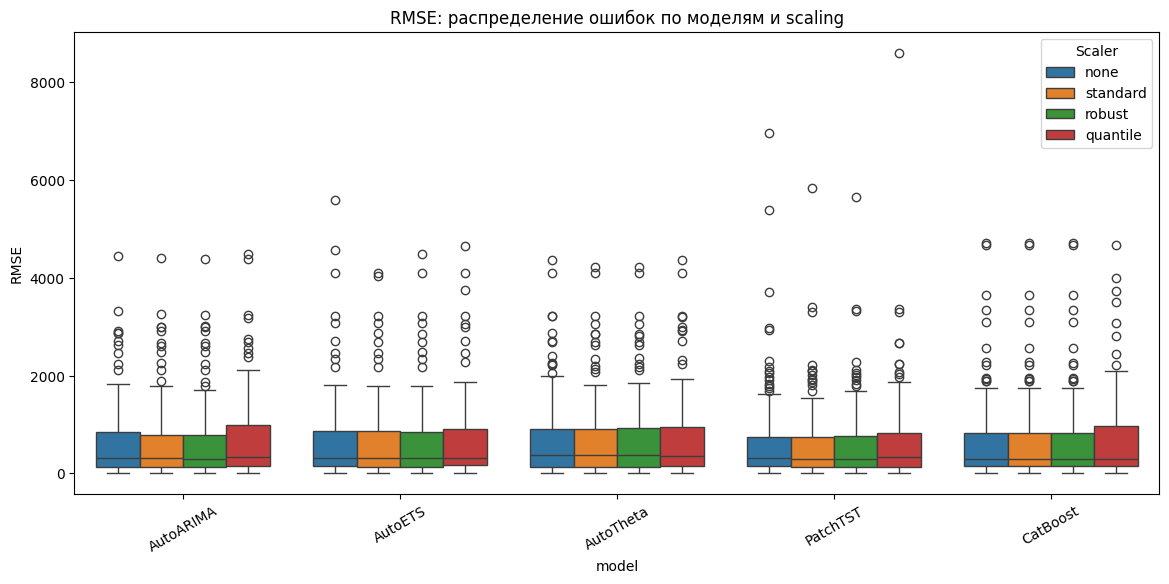

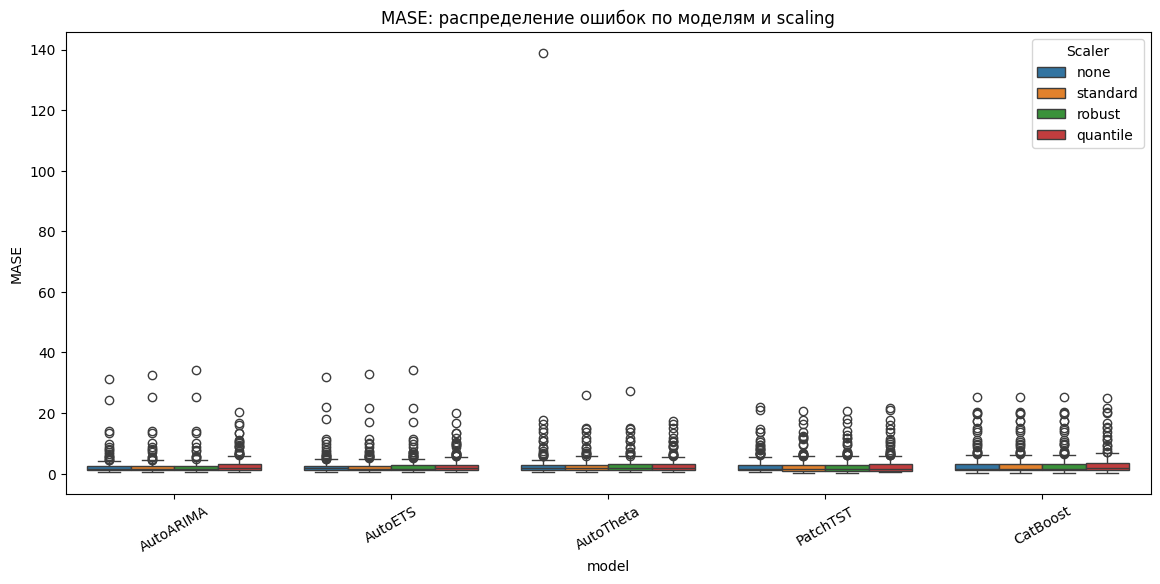

In [51]:
for metric in ['sMAPE', 'RMSE', 'MASE']:
  plt.figure(figsize=(14, 6))
  sns.boxplot(
      data=results_df,
      x='model',
      y=metric,
      hue='scaler'
  )

  plt.title(metric+': распределение ошибок по моделям и scaling')
  plt.xticks(rotation=30)
  plt.legend(title='Scaler')
  plt.show()

Значительной разницы в распределениях ошибки в зависимости от метода нормализации не наблюдается. Видно, что при quantile распределение оказывается несколько "шире", чем при других методах. Но здесь стоит сделать важное замечание: показатели ошибки считаются отдельно по каждому ряду и затем усредняются. Мы уже выяснили, насколько сильно различаются ряды между собой. Вполне вероятно, распределение ошибки в разрезе одного ряда отличалось бы куда больше, но тогда эксперимент нельзя было бы считать чистым: некоторые ряды сами по себе лучше подходят под опред. модели, чем иные, и их аппроксимирующая способность и вклад нормализации могли бы быть переоценены.

In [58]:
agg = results_df.groupby(['model', 'scaler']).agg({
    'MASE': 'mean',
    'sMAPE': 'mean',
    'RMSE': 'mean'
}).reset_index()

worst_mase = agg.loc[agg['MASE'].idxmin()]
best_rmse = agg.loc[agg['RMSE'].idxmin()]
best_smape = agg.loc[agg['sMAPE'].idxmin()]

print("Лучший по MASE:")
worst_mase

Лучший по MASE:


,3
model,AutoARIMA
scaler,standard
MASE,2.624247
sMAPE,10.831376
RMSE,621.208536


In [55]:
print("\nЛучший по RMSE:")
best_rmse


Лучший по RMSE:


,18
model,PatchTST
scaler,robust
MASE,2.783325
sMAPE,10.344112
RMSE,594.942632


In [56]:
print("\nЛучший по sMAPE:")
best_smape


Лучший по sMAPE:


,19
model,PatchTST
scaler,standard
MASE,2.754981
sMAPE,10.303117
RMSE,595.695801


По лидерам отдельно по каждой из метрик видно, что разные методы нормализации позволяют к тому же улучшать разные метрики. Так, например, для PatchTST sMAPE оказалась лучше при standard, а RMSE - при robust. Это важно учитывать, поскольку в реальных задачах и бизнес кейсах часто бывает важно, чтобы модель не просто хорошо аппроксимировала ряд, но и, например, лучше обрабатывала выбросы. В таком случае правильный выбор стратегии нормализации может помочь учесть эти требования лучше.